# Model Comparison Overview: All Classifiers on Test Split (Local / MacBook Pro)

Comprehensive evaluation of all four classification approaches on the **frozen test set**:

1. **Multinomial Naive Bayes** (TF-IDF + MultinomialNB)
2. **Zero-Shot DeBERTa-v3-large** (NLI-based)
3. **EuroBERT-210m Baseline** (fine-tuned, default hyperparameters)
4. **EuroBERT-210m + HPT** (fine-tuned, Optuna-optimized hyperparameters)

**Outputs:**
- F1 Macro overview table
- Confusion matrices (one per model)
- Pairwise F1 for three difficult class pairs
- Per-class F1 grouped bar chart (all 13 classes, all models)
- Full CSV export of all metrics

**Prerequisites:**
- `HF_TOKEN` environment variable set (e.g. `export HF_TOKEN=hf_...`)
- Python packages: `transformers`, `datasets`, `scikit-learn`, `matplotlib`, `seaborn`, `accelerate`
- Runs on Apple Silicon (MPS) or CPU — no GPU required.

In [1]:
# === SETUP (Local / MacBook Pro) ===
import os, sys
from pathlib import Path

# Project root (adjust if needed)
REPO = Path(__file__).resolve().parent.parent.parent if "__file__" in dir() else Path.cwd()
# Fallback: find repo root by looking for .git
_cwd = Path.cwd()
while _cwd != _cwd.parent:
    if (_cwd / ".git").exists():
        REPO = _cwd
        break
    _cwd = _cwd.parent

# Make pipeline_utils importable
PIPELINE_DIR = str(REPO / "Python" / "classification_pipeline" / "euroBERT_210m")
if PIPELINE_DIR not in sys.path:
    sys.path.insert(0, PIPELINE_DIR)

import importlib
import pipeline_utils as pu
importlib.reload(pu)

# HuggingFace Login
from huggingface_hub import login

hf_token = os.environ.get("HF_TOKEN")
if hf_token:
    login(token=hf_token)
    print("Logged in to HuggingFace.")
else:
    print("WARNING: HF_TOKEN not set. Set it via: export HF_TOKEN=hf_...")
    print("Trying without login (will fail for private repos).")

# --- Output directory: local ---
OUTPUT_DIR = REPO / "Python" / "classification_pipeline" / "local_output" / "overview_report"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Repo root: {REPO}")
print(f"Output directory: {OUTPUT_DIR}")
print("Setup complete.")

Trying without login (will fail for private repos).
Repo root: /Users/zorbeyozcan/news_articles_classification_thesis
Output directory: /Users/zorbeyozcan/news_articles_classification_thesis/Python/classification_pipeline/local_output/overview_report
Setup complete.


In [2]:
# === CONFIGURATION ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import f1_score

# Reproducibility
RANDOM_SEED = 42
TEST_PER_CLASS = 30

# All 13 class labels (must match dataset)
ALL_LABELS = [
    "Klima / Energie", "Zuwanderung", "Renten", "Soziales Gefälle",
    "AfD/Rechte", "Arbeitslosigkeit", "Wirtschaftslage", "Politikverdruss",
    "Gesundheitswesen, Pflege", "Kosten/Löhne/Preise",
    "Ukraine/Krieg/Russland", "Bundeswehr/Verteidigung", "Andere",
]

label2id = {label: idx for idx, label in enumerate(ALL_LABELS)}
id2label = {idx: label for idx, label in enumerate(ALL_LABELS)}

# Three difficult class pairs for pairwise analysis
DIFFICULT_PAIRS = [
    ("Arbeitslosigkeit", "Wirtschaftslage"),
    ("Ukraine/Krieg/Russland", "Bundeswehr/Verteidigung"),
    ("Zuwanderung", "AfD/Rechte"),
]

# Model display names (used in plots and tables)
MODEL_NAMES = [
    "Multinomial NB",
    "Zero-Shot DeBERTa",
    "EuroBERT Baseline",
    "EuroBERT + HPT",
]

# Plot style
MODEL_COLORS = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
plt.rcParams.update({"figure.dpi": 150, "savefig.dpi": 200, "font.size": 11})

print("Configuration loaded.")
print(f"Difficult pairs: {DIFFICULT_PAIRS}")

Configuration loaded.
Difficult pairs: [('Arbeitslosigkeit', 'Wirtschaftslage'), ('Ukraine/Krieg/Russland', 'Bundeswehr/Verteidigung'), ('Zuwanderung', 'AfD/Rechte')]


In [3]:
# === LOAD DATA & CREATE IDENTICAL SPLITS ===
# Identical split logic to all pipeline notebooks (01, 02, 04, NB, ZS).

from datasets import load_dataset

np.random.seed(RANDOM_SEED)

ds = load_dataset(pu.DATASET_ID)
train_hf = ds["train"].to_pandas()
test_hf = ds["test"].to_pandas()
all_labelled = pd.concat([train_hf, test_hf], ignore_index=True)

# Fixed stratified test split (identical to all notebooks)
test_indices = []
rest_indices = []

for label in ALL_LABELS:
    label_mask = all_labelled["label"] == label
    label_indices = all_labelled[label_mask].index.tolist()
    n_total = len(label_indices)
    if n_total < 60:
        n_test = n_total // 2
        print(f"  {label}: only {n_total} articles -> {n_test} for test")
    else:
        n_test = TEST_PER_CLASS
    np.random.shuffle(label_indices)
    test_indices.extend(label_indices[:n_test])
    rest_indices.extend(label_indices[n_test:])

test_df = all_labelled.loc[test_indices].reset_index(drop=True)
cv_pool_df = all_labelled.loc[rest_indices].reset_index(drop=True)

test_df["label_id"] = test_df["label"].map(label2id)
cv_pool_df["label_id"] = cv_pool_df["label"].map(label2id)

print(f"\nTest split:  {len(test_df)} articles (frozen)")
print(f"CV pool:     {len(cv_pool_df)} articles (training data)")
print(f"\nTest class distribution:")
print(test_df["label"].value_counts().to_string())

  Politikverdruss: only 50 articles -> 25 for test

Test split:  385 articles (frozen)
CV pool:     1975 articles (training data)

Test class distribution:
label
Klima / Energie             30
Zuwanderung                 30
Renten                      30
Soziales Gefälle            30
AfD/Rechte                  30
Arbeitslosigkeit            30
Wirtschaftslage             30
Gesundheitswesen, Pflege    30
Kosten/Löhne/Preise         30
Ukraine/Krieg/Russland      30
Bundeswehr/Verteidigung     30
Andere                      30
Politikverdruss             25


---
## Model 1: Multinomial Naive Bayes (TF-IDF)

In [4]:
# === MODEL 1: MULTINOMIAL NAIVE BAYES ===
print("=" * 60)
print("  MODEL 1: Multinomial Naive Bayes + TF-IDF")
print("=" * 60)

# TF-IDF config (identical to naive_bayes_baseline.ipynb)
TFIDF_MAX_FEATURES = 50_000
TFIDF_NGRAM_RANGE = (1, 2)
TFIDF_SUBLINEAR_TF = True
TFIDF_MIN_DF = 2
NB_ALPHA = 1.0

# Fit TF-IDF on CV pool, predict on test set
tfidf = TfidfVectorizer(
    max_features=TFIDF_MAX_FEATURES,
    ngram_range=TFIDF_NGRAM_RANGE,
    sublinear_tf=TFIDF_SUBLINEAR_TF,
    min_df=TFIDF_MIN_DF,
)
X_train = tfidf.fit_transform(cv_pool_df["text"])
X_test = tfidf.transform(test_df["text"])

clf_nb = MultinomialNB(alpha=NB_ALPHA)
clf_nb.fit(X_train, cv_pool_df["label_id"].values)

nb_pred_ids = clf_nb.predict(X_test)
nb_pred_labels = [id2label[i] for i in nb_pred_ids]
nb_true_labels = test_df["label"].tolist()

nb_metrics = pu.evaluate(nb_true_labels, nb_pred_labels, labels=ALL_LABELS, experiment_name="test")
pu.print_metrics(nb_metrics, "Multinomial Naive Bayes")

# Free memory
del X_train, X_test, tfidf, clf_nb
print("Model 1 complete.")

  MODEL 1: Multinomial Naive Bayes + TF-IDF
  Multinomial Naive Bayes

  F1 Macro:           0.6737
  F1 Weighted:        0.6782
  Precision Macro:    0.7791
  Precision Weighted: 0.7762
  Recall Macro:       0.6949
  Recall Weighted:    0.7013
  Accuracy:           0.7013

  Per-Class Metrics:
                   Label  Precision   Recall       F1  Support
         Klima / Energie   0.781250 0.833333 0.806452       30
             Zuwanderung   0.520833 0.833333 0.641026       30
                  Renten   0.604651 0.866667 0.712329       30
        Soziales Gefälle   1.000000 0.166667 0.285714       30
              AfD/Rechte   0.594595 0.733333 0.656716       30
        Arbeitslosigkeit   1.000000 0.533333 0.695652       30
         Wirtschaftslage   0.600000 0.800000 0.685714       30
         Politikverdruss   1.000000 0.200000 0.333333       25
Gesundheitswesen, Pflege   0.725000 0.966667 0.828571       30
     Kosten/Löhne/Preise   0.733333 0.733333 0.733333       30
  Ukraine/K

---
## Model 2: Zero-Shot DeBERTa-v3-large (NLI)

In [5]:
# === MODEL 2: ZERO-SHOT DeBERTa-v3-large ===
import gc
import torch
from transformers import pipeline as hf_pipeline
from tqdm.auto import tqdm

print("=" * 60)
print("  MODEL 2: Zero-Shot DeBERTa-v3-large (NLI)")
print("=" * 60)

ZS_MODEL_ID = "MoritzLaurer/deberta-v3-large-zeroshot-v1.1-all-33"
HYPOTHESIS_TEMPLATE = "Dieser Text handelt {}."
CONFIDENCE_THRESHOLD = 0.4
ZS_BATCH_SIZE = 8  # smaller batch for local memory

# NLI verbalizations (identical to zero_shot_bert notebook)
ZS_LABEL_MAPPING = {
    "Klima / Energie":          "vom Klima, Klimawandel oder der Energieversorgung",
    "Zuwanderung":              "von Zuwanderung oder Migration",
    "Renten":                   "von der Rente oder dem Rentensystem",
    "Soziales Gefälle":         "vom Sozialen Gefälle oder von sozialer Ungleicheit",
    "AfD/Rechte":               "von der Brandmauer, der AfD oder dem Rechtsextremismus",
    "Arbeitslosigkeit":         "von Arbeitslosigkeit",
    "Wirtschaftslage":          "von der Wirtschaftslage oder der Zukunft der Deutschen Wirtschaft",
    "Politikverdruss":          "von Politikverdruss, dem Vertrauen in die Demokraite oder der Interesse für Politik bei den Bürgern",
    "Gesundheitswesen, Pflege": "vom Gesundheitswesen, der Pflege oder Krankenversicherungen",
    "Kosten/Löhne/Preise":      "von steigenden Preisen und Lebenshaltungskosten oder von Löhnen",
    "Ukraine/Krieg/Russland":   "vom Ukraine Krieg oder von Russland",
    "Bundeswehr/Verteidigung":  "von der Bundeswehr, der Verteidigung Deutschlands oder Investitionen in die Rüstung",
}

ZS_CANDIDATE_LABELS = list(ZS_LABEL_MAPPING.values())
# Reverse map: verbalization -> original label
zs_reverse_map = {v: k for k, v in ZS_LABEL_MAPPING.items()}

# Device selection: MPS (Apple Silicon) > CUDA > CPU
if torch.backends.mps.is_available():
    device = "mps"
    _torch_dtype = torch.float32  # MPS does not support float16 well
    print("Using Apple Silicon MPS backend")
elif torch.cuda.is_available():
    device = 0
    _torch_dtype = torch.float16
    print("Using CUDA GPU")
else:
    device = -1
    _torch_dtype = torch.float32
    print("Using CPU")

zs_classifier = hf_pipeline(
    "zero-shot-classification",
    model=ZS_MODEL_ID,
    device=device,
    torch_dtype=_torch_dtype,
)
print(f"Model loaded: {ZS_MODEL_ID}")

  MODEL 2: Zero-Shot DeBERTa-v3-large (NLI)
Using Apple Silicon MPS backend


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/394 [00:00<?, ?it/s]

Model loaded: MoritzLaurer/deberta-v3-large-zeroshot-v1.1-all-33


In [6]:
# Run zero-shot classification on test set
texts = test_df["text"].fillna("").tolist()
zs_predictions = []
threshold_count = 0

for start in tqdm(range(0, len(texts), ZS_BATCH_SIZE), desc="Zero-Shot classifying"):
    batch_texts = texts[start:start + ZS_BATCH_SIZE]
    results = zs_classifier(
        batch_texts,
        candidate_labels=ZS_CANDIDATE_LABELS,
        hypothesis_template=HYPOTHESIS_TEMPLATE,
        multi_label=False,
    )
    if isinstance(results, dict):
        results = [results]

    for r in results:
        top_verb = r["labels"][0]
        top_score = r["scores"][0]
        if top_score < CONFIDENCE_THRESHOLD:
            zs_predictions.append("Andere")
            threshold_count += 1
        else:
            zs_predictions.append(zs_reverse_map[top_verb])

print(f"Threshold -> 'Andere': {threshold_count} articles")

zs_true_labels = test_df["label"].tolist()
zs_metrics = pu.evaluate(zs_true_labels, zs_predictions, labels=ALL_LABELS, experiment_name="test")
pu.print_metrics(zs_metrics, "Zero-Shot DeBERTa-v3-large")

# Free memory
del zs_classifier
gc.collect()
if torch.backends.mps.is_available():
    torch.mps.empty_cache()
elif torch.cuda.is_available():
    torch.cuda.empty_cache()
print("Model 2 complete.")

Zero-Shot classifying:   0%|          | 0/49 [00:00<?, ?it/s]

Threshold -> 'Andere': 39 articles
  Zero-Shot DeBERTa-v3-large

  F1 Macro:           0.7255
  F1 Weighted:        0.7257
  Precision Macro:    0.7505
  Precision Weighted: 0.7499
  Recall Macro:       0.7338
  Recall Weighted:    0.7351
  Accuracy:           0.7351

  Per-Class Metrics:
                   Label  Precision   Recall       F1  Support
         Klima / Energie   0.828571 0.966667 0.892308       30
             Zuwanderung   0.685714 0.800000 0.738462       30
                  Renten   0.925926 0.833333 0.877193       30
        Soziales Gefälle   0.714286 0.500000 0.588235       30
              AfD/Rechte   0.782609 0.600000 0.679245       30
        Arbeitslosigkeit   0.875000 0.700000 0.777778       30
         Wirtschaftslage   0.480769 0.833333 0.609756       30
         Politikverdruss   0.800000 0.640000 0.711111       25
Gesundheitswesen, Pflege   0.805556 0.966667 0.878788       30
     Kosten/Löhne/Preise   0.583333 0.233333 0.333333       30
  Ukraine/Krieg/R

---
## Model 3: EuroBERT-210m Baseline (Fine-Tuned)

In [7]:
# === MODEL 3: EuroBERT-210m BASELINE ===
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AutoConfig
from transformers.modeling_rope_utils import ROPE_INIT_FUNCTIONS
from torch.utils.data import DataLoader, Dataset as TorchDataset

print("=" * 60)
print("  MODEL 3: EuroBERT-210m Baseline (Fine-Tuned)")
print("=" * 60)

BASELINE_REPO = "Zorryy/NewsBERT-germ-210m_baseline"
MAX_LENGTH = 2048
EVAL_BATCH_SIZE = 8  # smaller batch for local memory

# EuroBERT RoPE fix
def _default_rope_init(config, device=None, **kwargs):
    base = getattr(config, "rope_theta", 10000.0)
    partial_rotary_factor = getattr(config, "partial_rotary_factor", 1.0)
    head_dim = getattr(config, "head_dim", config.hidden_size // config.num_attention_heads)
    dim = int(head_dim * partial_rotary_factor)
    inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2, dtype=torch.int64).float().to(device) / dim))
    return inv_freq, 1.0

ROPE_INIT_FUNCTIONS["default"] = _default_rope_init


def predict_eurobert(repo_id, test_df, max_length=MAX_LENGTH, batch_size=EVAL_BATCH_SIZE):
    """Load a fine-tuned EuroBERT model and predict on test_df.

    Uses MPS on Apple Silicon, CUDA if available, otherwise CPU.
    Logits are cast to float32 to avoid NaN from EuroBERT BF16 attention.
    """
    tokenizer = AutoTokenizer.from_pretrained(repo_id, trust_remote_code=True)
    model = AutoModelForSequenceClassification.from_pretrained(
        repo_id, trust_remote_code=True
    )
    model.eval()

    # Device selection: MPS > CUDA > CPU
    if torch.backends.mps.is_available():
        device_obj = torch.device("mps")
    elif torch.cuda.is_available():
        device_obj = torch.device("cuda")
    else:
        device_obj = torch.device("cpu")

    print(f"  Device: {device_obj}")
    model = model.to(device_obj)

    # Ensure id2label keys are ints (HF config.json stores them as strings)
    model_id2label = {int(k): v for k, v in model.config.id2label.items()}
    print(f"  Model id2label: {model_id2label}")

    texts = test_df["text"].fillna("").tolist()
    predictions = []
    nan_count = 0

    for start in tqdm(range(0, len(texts), batch_size), desc=f"Predicting ({repo_id.split('/')[-1]})"):
        batch_texts = texts[start:start + batch_size]
        encodings = tokenizer(
            batch_texts, max_length=max_length, truncation=True,
            padding=True, return_tensors="pt"
        )
        encodings = {k: v.to(device_obj) for k, v in encodings.items()}

        with torch.no_grad():
            outputs = model(**encodings)
            # Cast to float32 to avoid NaN from EuroBERT BF16 attention
            logits = outputs.logits.float()

            # Check for NaN logits
            if torch.isnan(logits).any():
                nan_count += logits.shape[0]
                logits = torch.nan_to_num(logits, nan=0.0)

            pred_ids = logits.argmax(dim=-1).cpu().numpy()

        for pid in pred_ids:
            predictions.append(model_id2label[int(pid)])

    if nan_count > 0:
        print(f"  WARNING: {nan_count} samples had NaN logits!")

    # Free memory
    del model
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()
    elif torch.cuda.is_available():
        torch.cuda.empty_cache()

    return predictions


# Predict with baseline model
baseline_pred_labels = predict_eurobert(BASELINE_REPO, test_df)
baseline_true_labels = test_df["label"].tolist()

baseline_metrics = pu.evaluate(
    baseline_true_labels, baseline_pred_labels,
    labels=ALL_LABELS, experiment_name="test"
)
pu.print_metrics(baseline_metrics, "EuroBERT-210m Baseline")
print("Model 3 complete.")

  MODEL 3: EuroBERT-210m Baseline (Fine-Tuned)


--- Logging error ---
Traceback (most recent call last):
  File "/Users/zorbeyozcan/anaconda3/lib/python3.11/logging/__init__.py", line 1110, in emit
    msg = self.format(record)
          ^^^^^^^^^^^^^^^^^^^
  File "/Users/zorbeyozcan/anaconda3/lib/python3.11/logging/__init__.py", line 953, in format
    return fmt.format(record)
           ^^^^^^^^^^^^^^^^^^
  File "/Users/zorbeyozcan/anaconda3/lib/python3.11/logging/__init__.py", line 687, in format
    record.message = record.getMessage()
                     ^^^^^^^^^^^^^^^^^^^
  File "/Users/zorbeyozcan/anaconda3/lib/python3.11/logging/__init__.py", line 377, in getMessage
    msg = msg % self.args
          ~~~~^~~~~~~~~~~
TypeError: not all arguments converted during string formatting
Call stack:
  File "/Users/zorbeyozcan/anaconda3/lib/python3.11/runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "/Users/zorbeyozcan/anaconda3/lib/python3.11/runpy.py", line 88, in _run_code
    ex

Loading weights:   0%|          | 0/114 [00:00<?, ?it/s]

  Device: mps
  Model id2label: {0: 'Klima / Energie', 1: 'Zuwanderung', 2: 'Renten', 3: 'Soziales Gefälle', 4: 'AfD/Rechte', 5: 'Arbeitslosigkeit', 6: 'Wirtschaftslage', 7: 'Politikverdruss', 8: 'Gesundheitswesen, Pflege', 9: 'Kosten/Löhne/Preise', 10: 'Ukraine/Krieg/Russland', 11: 'Bundeswehr/Verteidigung', 12: 'Andere'}


Predicting (NewsBERT-germ-210m_baseline):   0%|          | 0/49 [00:00<?, ?it/s]

  EuroBERT-210m Baseline

  F1 Macro:           0.7609
  F1 Weighted:        0.7672
  Precision Macro:    0.8078
  Precision Weighted: 0.8053
  Recall Macro:       0.7687
  Recall Weighted:    0.7766
  Accuracy:           0.7766

  Per-Class Metrics:
                   Label  Precision   Recall       F1  Support
         Klima / Energie   0.862069 0.833333 0.847458       30
             Zuwanderung   0.685714 0.800000 0.738462       30
                  Renten   0.962963 0.866667 0.912281       30
        Soziales Gefälle   0.450000 0.600000 0.514286       30
              AfD/Rechte   0.705882 0.800000 0.750000       30
        Arbeitslosigkeit   0.956522 0.733333 0.830189       30
         Wirtschaftslage   0.764706 0.866667 0.812500       30
         Politikverdruss   1.000000 0.160000 0.275862       25
Gesundheitswesen, Pflege   0.896552 0.866667 0.881356       30
     Kosten/Löhne/Preise   0.727273 0.800000 0.761905       30
  Ukraine/Krieg/Russland   0.833333 1.000000 0.909091   

---
## Model 4: EuroBERT-210m + HPT (Optuna-Optimized)

In [8]:
# === MODEL 4: EuroBERT-210m + HPT ===
print("=" * 60)
print("  MODEL 4: EuroBERT-210m + HPT (Optuna-Optimized)")
print("=" * 60)

HPT_REPO = "Zorryy/NewsBERT-germ-210m"

hpt_pred_labels = predict_eurobert(HPT_REPO, test_df)
hpt_true_labels = test_df["label"].tolist()

hpt_metrics = pu.evaluate(
    hpt_true_labels, hpt_pred_labels,
    labels=ALL_LABELS, experiment_name="test"
)
pu.print_metrics(hpt_metrics, "EuroBERT-210m + HPT")
print("Model 4 complete.")

  MODEL 4: EuroBERT-210m + HPT (Optuna-Optimized)


Loading weights:   0%|          | 0/114 [00:00<?, ?it/s]

  Device: mps
  Model id2label: {0: 'Klima / Energie', 1: 'Zuwanderung', 2: 'Renten', 3: 'Soziales Gefälle', 4: 'AfD/Rechte', 5: 'Arbeitslosigkeit', 6: 'Wirtschaftslage', 7: 'Politikverdruss', 8: 'Gesundheitswesen, Pflege', 9: 'Kosten/Löhne/Preise', 10: 'Ukraine/Krieg/Russland', 11: 'Bundeswehr/Verteidigung', 12: 'Andere'}


Predicting (NewsBERT-germ-210m):   0%|          | 0/49 [00:00<?, ?it/s]

  EuroBERT-210m + HPT

  F1 Macro:           0.8204
  F1 Weighted:        0.8207
  Precision Macro:    0.8387
  Precision Weighted: 0.8379
  Recall Macro:       0.8169
  Recall Weighted:    0.8182
  Accuracy:           0.8182

  Per-Class Metrics:
                   Label  Precision   Recall       F1  Support
         Klima / Energie   0.787879 0.866667 0.825397       30
             Zuwanderung   0.838710 0.866667 0.852459       30
                  Renten   0.857143 0.800000 0.827586       30
        Soziales Gefälle   0.678571 0.633333 0.655172       30
              AfD/Rechte   0.793103 0.766667 0.779661       30
        Arbeitslosigkeit   1.000000 0.700000 0.823529       30
         Wirtschaftslage   0.560000 0.933333 0.700000       30
         Politikverdruss   0.900000 0.720000 0.800000       25
Gesundheitswesen, Pflege   0.903226 0.933333 0.918033       30
     Kosten/Löhne/Preise   0.920000 0.766667 0.836364       30
  Ukraine/Krieg/Russland   0.935484 0.966667 0.950820      

---
## Collect All Results

In [9]:
# === COLLECT ALL METRICS ===
all_metrics = [nb_metrics, zs_metrics, baseline_metrics, hpt_metrics]

# --- 1. Overview table: aggregate metrics ---
overview_rows = []
for name, m in zip(MODEL_NAMES, all_metrics):
    overview_rows.append({
        "Model": name,
        "F1 Macro": round(m["f1_macro"], 4),
        "F1 Weighted": round(m["f1_weighted"], 4),
        "Precision Macro": round(m["precision_macro"], 4),
        "Precision Weighted": round(m["precision_weighted"], 4),
        "Recall Macro": round(m["recall_macro"], 4),
        "Recall Weighted": round(m["recall_weighted"], 4),
        "Accuracy": round(m["accuracy"], 4),
    })

overview_df = pd.DataFrame(overview_rows)
print("\n" + "=" * 70)
print("  AGGREGATE METRICS: ALL MODELS")
print("=" * 70)
print(overview_df.to_string(index=False))

# --- 2. Per-class F1 table ---
perclass_rows = []
for label in ALL_LABELS:
    row = {"Label": label}
    for name, m in zip(MODEL_NAMES, all_metrics):
        pc = m["per_class_df"]
        f1_val = pc.loc[pc["Label"] == label, "F1"].values[0]
        row[f"{name} F1"] = round(f1_val, 4)
        prec_val = pc.loc[pc["Label"] == label, "Precision"].values[0]
        row[f"{name} Precision"] = round(prec_val, 4)
        rec_val = pc.loc[pc["Label"] == label, "Recall"].values[0]
        row[f"{name} Recall"] = round(rec_val, 4)
        sup_val = pc.loc[pc["Label"] == label, "Support"].values[0]
        row[f"{name} Support"] = int(sup_val)
    perclass_rows.append(row)

perclass_df = pd.DataFrame(perclass_rows)
print("\nPer-class F1 scores:")
f1_cols = ["Label"] + [f"{n} F1" for n in MODEL_NAMES]
print(perclass_df[f1_cols].to_string(index=False))


  AGGREGATE METRICS: ALL MODELS
            Model  F1 Macro  F1 Weighted  Precision Macro  Precision Weighted  Recall Macro  Recall Weighted  Accuracy
   Multinomial NB    0.6737       0.6782           0.7791              0.7762        0.6949           0.7013    0.7013
Zero-Shot DeBERTa    0.7255       0.7257           0.7505              0.7499        0.7338           0.7351    0.7351
EuroBERT Baseline    0.7609       0.7672           0.8078              0.8053        0.7687           0.7766    0.7766
   EuroBERT + HPT    0.8204       0.8207           0.8387              0.8379        0.8169           0.8182    0.8182

Per-class F1 scores:
                   Label  Multinomial NB F1  Zero-Shot DeBERTa F1  EuroBERT Baseline F1  EuroBERT + HPT F1
         Klima / Energie             0.8065                0.8923                0.8475             0.8254
             Zuwanderung             0.6410                0.7385                0.7385             0.8525
                  Renten     

---
## Plot 1: F1 Macro Overview (All Models)

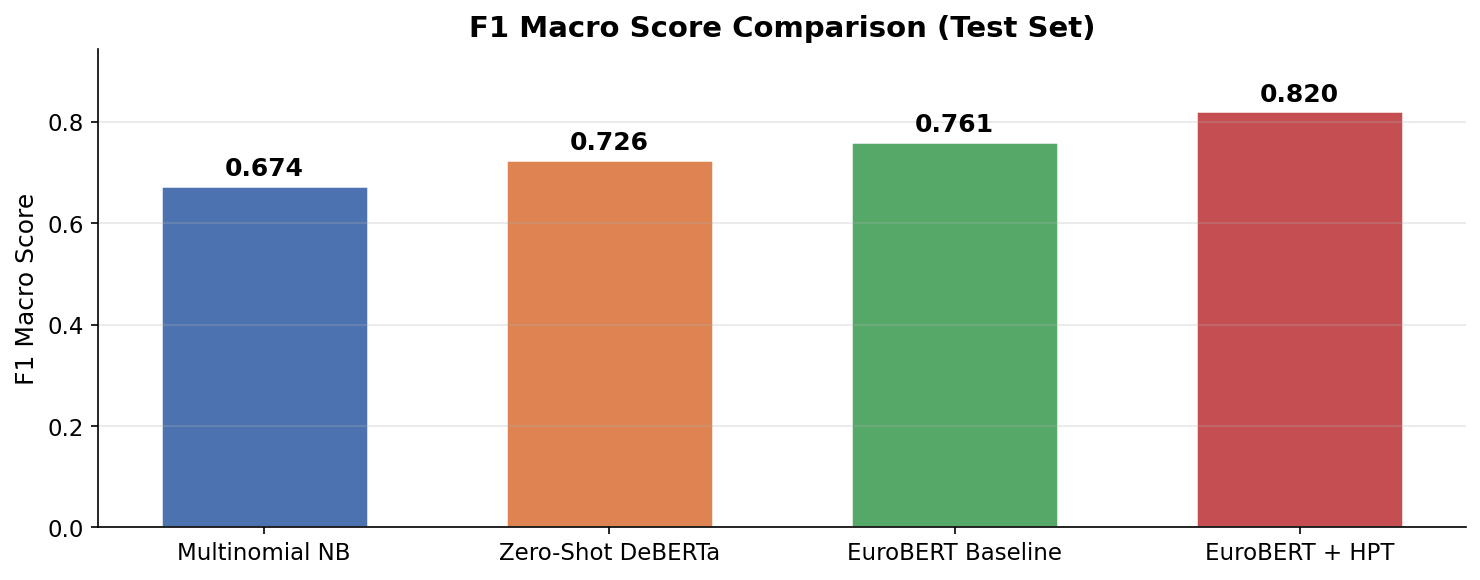

Saved: /Users/zorbeyozcan/news_articles_classification_thesis/Python/classification_pipeline/local_output/overview_report/01_f1_macro_overview.png


In [10]:
# === PLOT 1: F1 MACRO OVERVIEW TABLE ===
fig, ax = plt.subplots(figsize=(10, 4))

f1_values = [m["f1_macro"] for m in all_metrics]
x = np.arange(len(MODEL_NAMES))
bars = ax.bar(x, f1_values, color=MODEL_COLORS, width=0.6, edgecolor="white", linewidth=1.2)

# Add value labels on bars
for bar, val in zip(bars, f1_values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(MODEL_NAMES, fontsize=11)
ax.set_ylabel("F1 Macro Score", fontsize=12)
ax.set_title("F1 Macro Score Comparison (Test Set)", fontsize=14, fontweight="bold")
ax.set_ylim(0, max(f1_values) * 1.15)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
save_path = OUTPUT_DIR / "01_f1_macro_overview.png"
fig.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

---
## Plot 2: Confusion Matrices (One per Model)

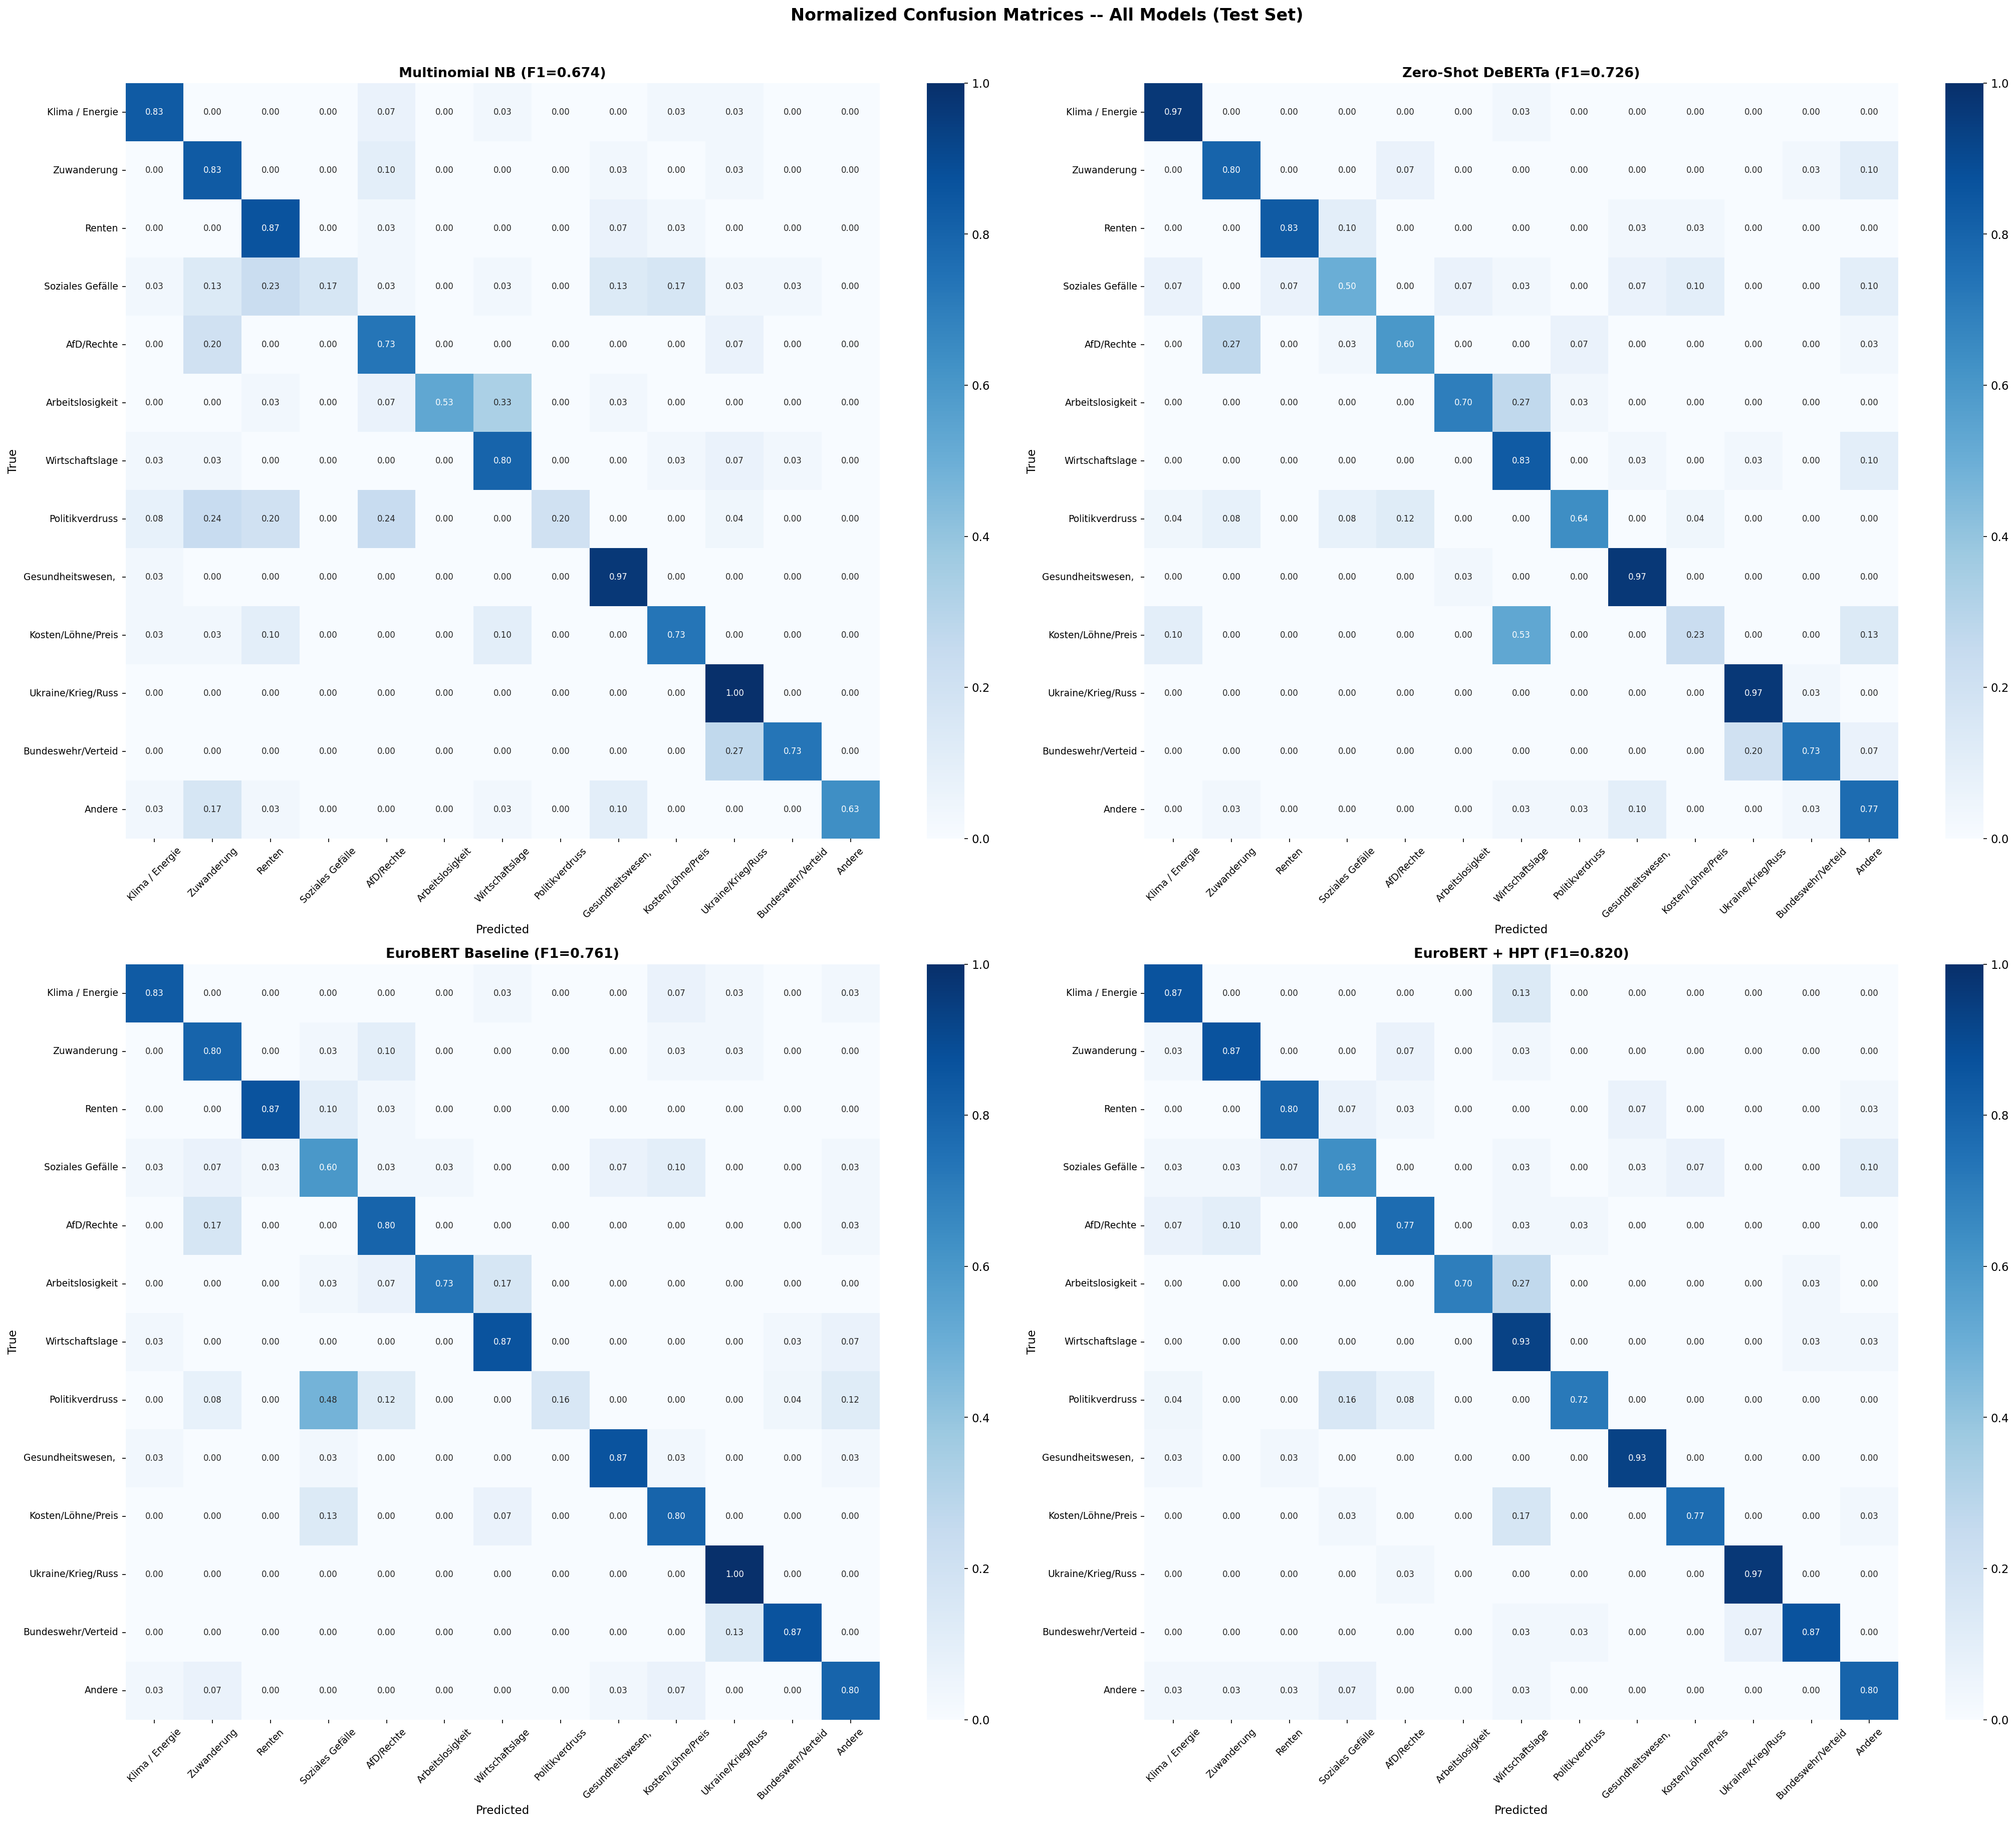

Saved: /Users/zorbeyozcan/news_articles_classification_thesis/Python/classification_pipeline/local_output/overview_report/02_confusion_matrices.png


In [11]:
# === PLOT 2: CONFUSION MATRICES (normalized, one per model) ===
fig, axes = plt.subplots(2, 2, figsize=(28, 24))
short_labels = [l[:18] for l in ALL_LABELS]

for idx, (name, m) in enumerate(zip(MODEL_NAMES, all_metrics)):
    ax = axes[idx // 2, idx % 2]
    cm_norm = m["confusion_matrix_normalized"]

    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=short_labels, yticklabels=short_labels,
        ax=ax, vmin=0, vmax=1,
        annot_kws={"fontsize": 8},
    )
    ax.set_xlabel("Predicted", fontsize=11)
    ax.set_ylabel("True", fontsize=11)
    ax.set_title(f"{name} (F1={m['f1_macro']:.3f})", fontsize=13, fontweight="bold")
    ax.tick_params(axis="x", rotation=45, labelsize=9)
    ax.tick_params(axis="y", rotation=0, labelsize=9)

plt.suptitle("Normalized Confusion Matrices -- All Models (Test Set)",
             fontsize=16, fontweight="bold", y=1.01)
plt.tight_layout()
save_path = OUTPUT_DIR / "02_confusion_matrices.png"
fig.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

---
## Plot 3: Pairwise F1 Macro for Difficult Class Pairs

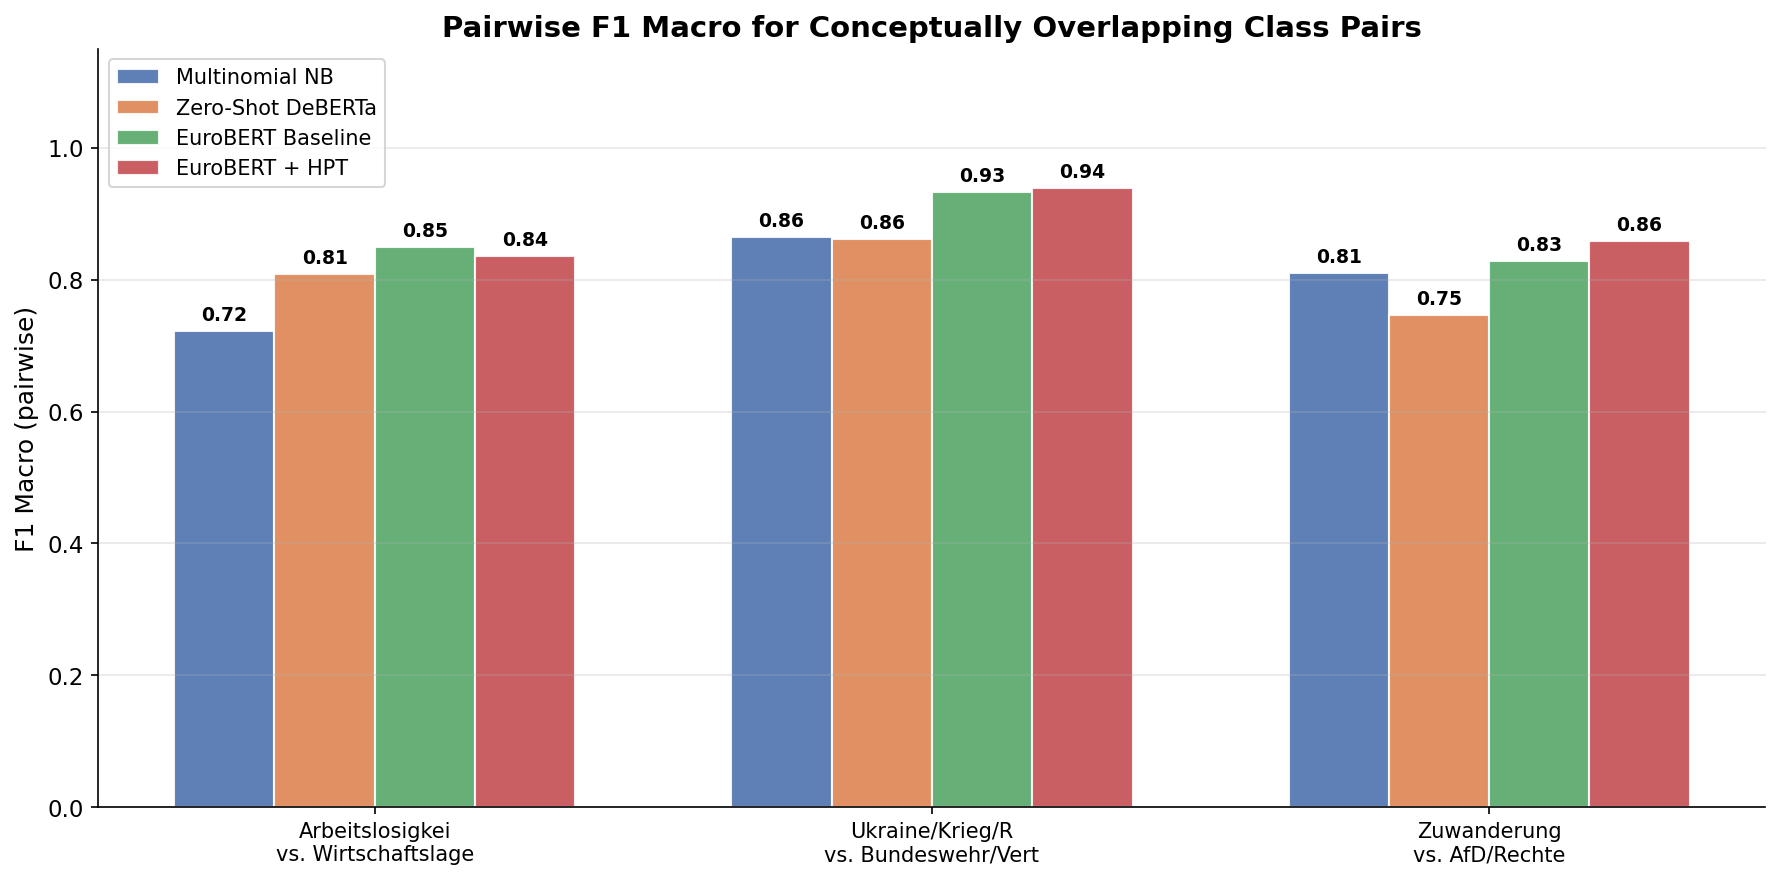

Saved: /Users/zorbeyozcan/news_articles_classification_thesis/Python/classification_pipeline/local_output/overview_report/03_pairwise_f1_difficult_pairs.png

Pairwise F1 Macro (difficult class pairs):
Pair               Arbeitslosigkeit\nvs. Wirtschaftslage  Ukraine/Krieg/Russland\nvs. Bundeswehr/Verteidigung  Zuwanderung\nvs. AfD/Rechte
Model                                                                                                                                     
EuroBERT + HPT                                    0.8360                                               0.9397                       0.8589
EuroBERT Baseline                                 0.8493                                               0.9330                       0.8278
Multinomial NB                                    0.7228                                               0.8643                       0.8098
Zero-Shot DeBERTa                                 0.8086                                               0

In [12]:
# === PLOT 3: PAIRWISE F1 MACRO FOR DIFFICULT CLASS PAIRS ===

def pairwise_f1_macro(y_true, y_pred, class_a, class_b):
    """Compute F1 macro restricted to samples belonging to class_a or class_b."""
    mask = [(t in (class_a, class_b)) for t in y_true]
    y_true_sub = [t for t, m in zip(y_true, mask) if m]
    y_pred_sub = [p for p, m in zip(y_pred, mask) if m]
    if len(y_true_sub) == 0:
        return 0.0
    return f1_score(y_true_sub, y_pred_sub, labels=[class_a, class_b],
                    average="macro", zero_division=0)


# Get prediction lists for each model
all_pred_lists = [nb_pred_labels, zs_predictions, baseline_pred_labels, hpt_pred_labels]
true_labels_list = test_df["label"].tolist()

# Compute pairwise F1 for each pair and model
pair_results = []
for class_a, class_b in DIFFICULT_PAIRS:
    for model_name, preds in zip(MODEL_NAMES, all_pred_lists):
        pw_f1 = pairwise_f1_macro(true_labels_list, preds, class_a, class_b)
        pair_results.append({
            "Pair": f"{class_a}\nvs. {class_b}",
            "Pair_short": f"{class_a[:15]} vs.\n{class_b[:15]}",
            "Model": model_name,
            "F1 Macro (pair)": pw_f1,
        })

pair_df = pd.DataFrame(pair_results)

# Grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))

pair_labels = [f"{a[:15]}\nvs. {b[:15]}" for a, b in DIFFICULT_PAIRS]
n_pairs = len(DIFFICULT_PAIRS)
n_models = len(MODEL_NAMES)
x = np.arange(n_pairs)
width = 0.18

for i, model_name in enumerate(MODEL_NAMES):
    model_vals = pair_df[pair_df["Model"] == model_name]["F1 Macro (pair)"].values
    offset = (i - n_models / 2 + 0.5) * width
    bars = ax.bar(x + offset, model_vals, width, label=model_name,
                  color=MODEL_COLORS[i], alpha=0.9, edgecolor="white")
    # Value labels
    for bar, val in zip(bars, model_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(pair_labels, fontsize=10)
ax.set_ylabel("F1 Macro (pairwise)", fontsize=12)
ax.set_title("Pairwise F1 Macro for Conceptually Overlapping Class Pairs",
             fontsize=14, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.legend(loc="upper left", fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
save_path = OUTPUT_DIR / "03_pairwise_f1_difficult_pairs.png"
fig.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

# Print pairwise results
print("\nPairwise F1 Macro (difficult class pairs):")
pivot = pair_df.pivot(index="Model", columns="Pair", values="F1 Macro (pair)")
print(pivot.round(4).to_string())

---
## Plot 3b: Individual F1 Scores for "Politikverdruss" and "Soziales Gefälle"

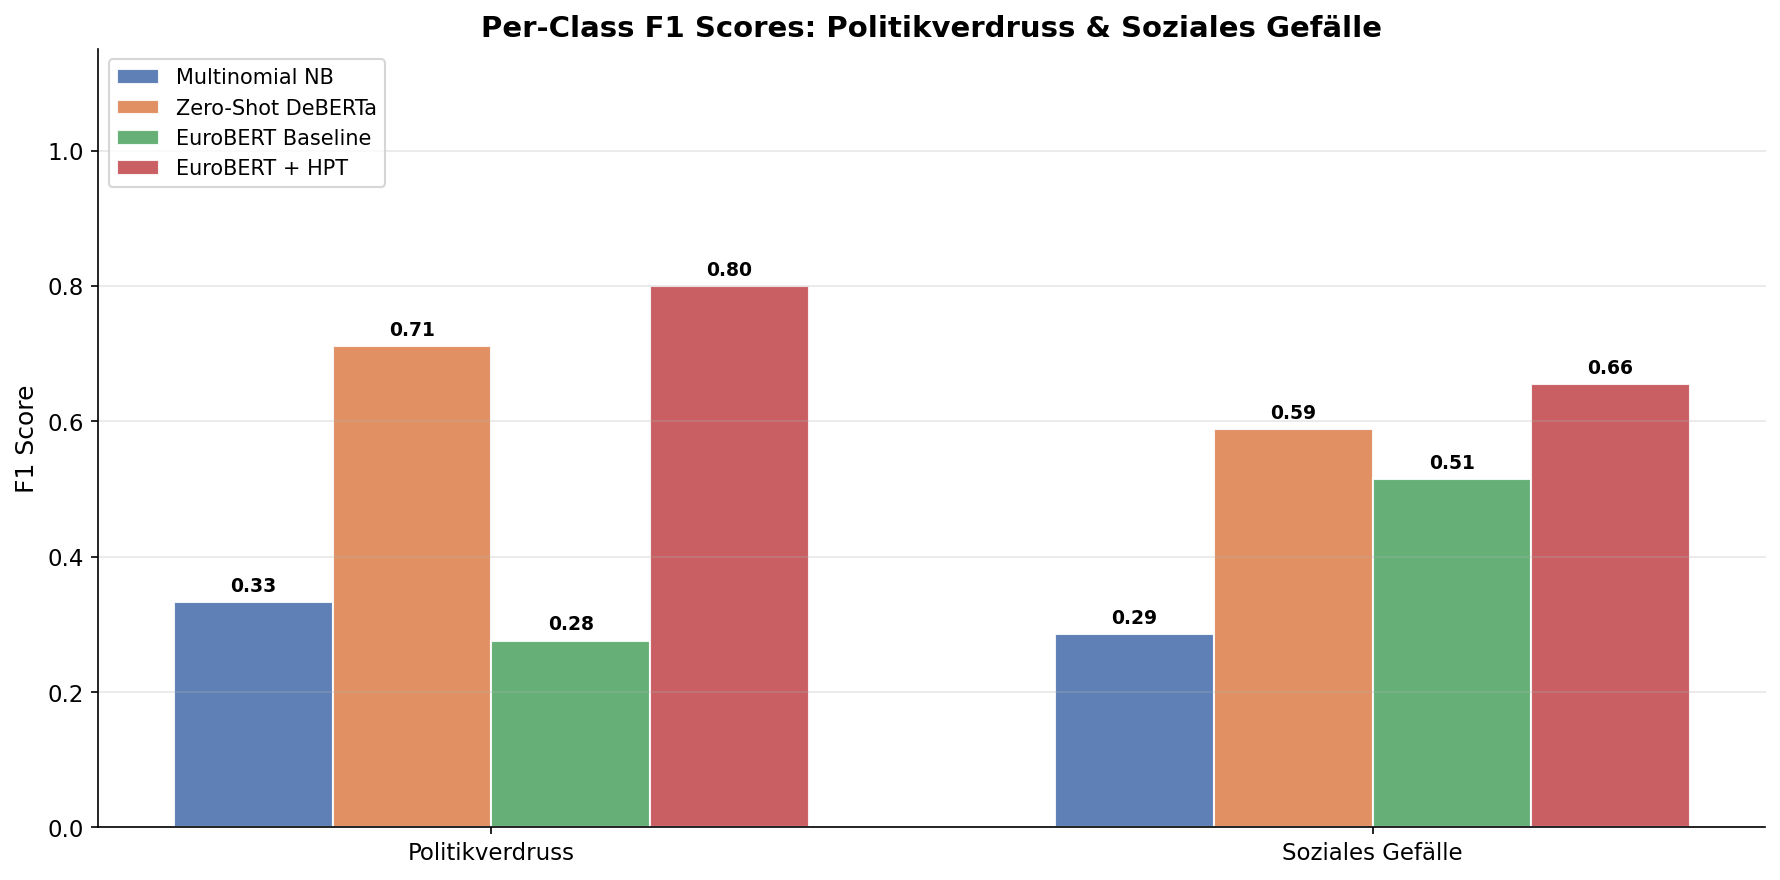

Saved: /Users/zorbeyozcan/news_articles_classification_thesis/Python/classification_pipeline/local_output/overview_report/03b_f1_politikverdruss_soziales_gefaelle.png


In [13]:
# === PLOT 3b: INDIVIDUAL F1 FOR "Politikverdruss" & "Soziales Gefälle" ===

FOCUS_CLASSES = ["Politikverdruss", "Soziales Gefälle"]

fig, ax = plt.subplots(figsize=(12, 6))

n_classes = len(FOCUS_CLASSES)
n_models = len(MODEL_NAMES)
x = np.arange(n_classes)
width = 0.18

for i, (name, m) in enumerate(zip(MODEL_NAMES, all_metrics)):
    pc = m["per_class_df"]
    f1_vals = [pc.loc[pc["Label"] == cls, "F1"].values[0] for cls in FOCUS_CLASSES]
    offset = (i - n_models / 2 + 0.5) * width
    bars = ax.bar(x + offset, f1_vals, width, label=name,
                  color=MODEL_COLORS[i], alpha=0.9, edgecolor="white")
    for bar, val in zip(bars, f1_vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f"{val:.2f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(FOCUS_CLASSES, fontsize=11)
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_title("Per-Class F1 Scores: Politikverdruss & Soziales Gefälle",
             fontsize=14, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.legend(loc="upper left", fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
save_path = OUTPUT_DIR / "03b_f1_politikverdruss_soziales_gefaelle.png"
fig.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

---
## Plot 4: Per-Class F1 Score (All Classes, All Models)

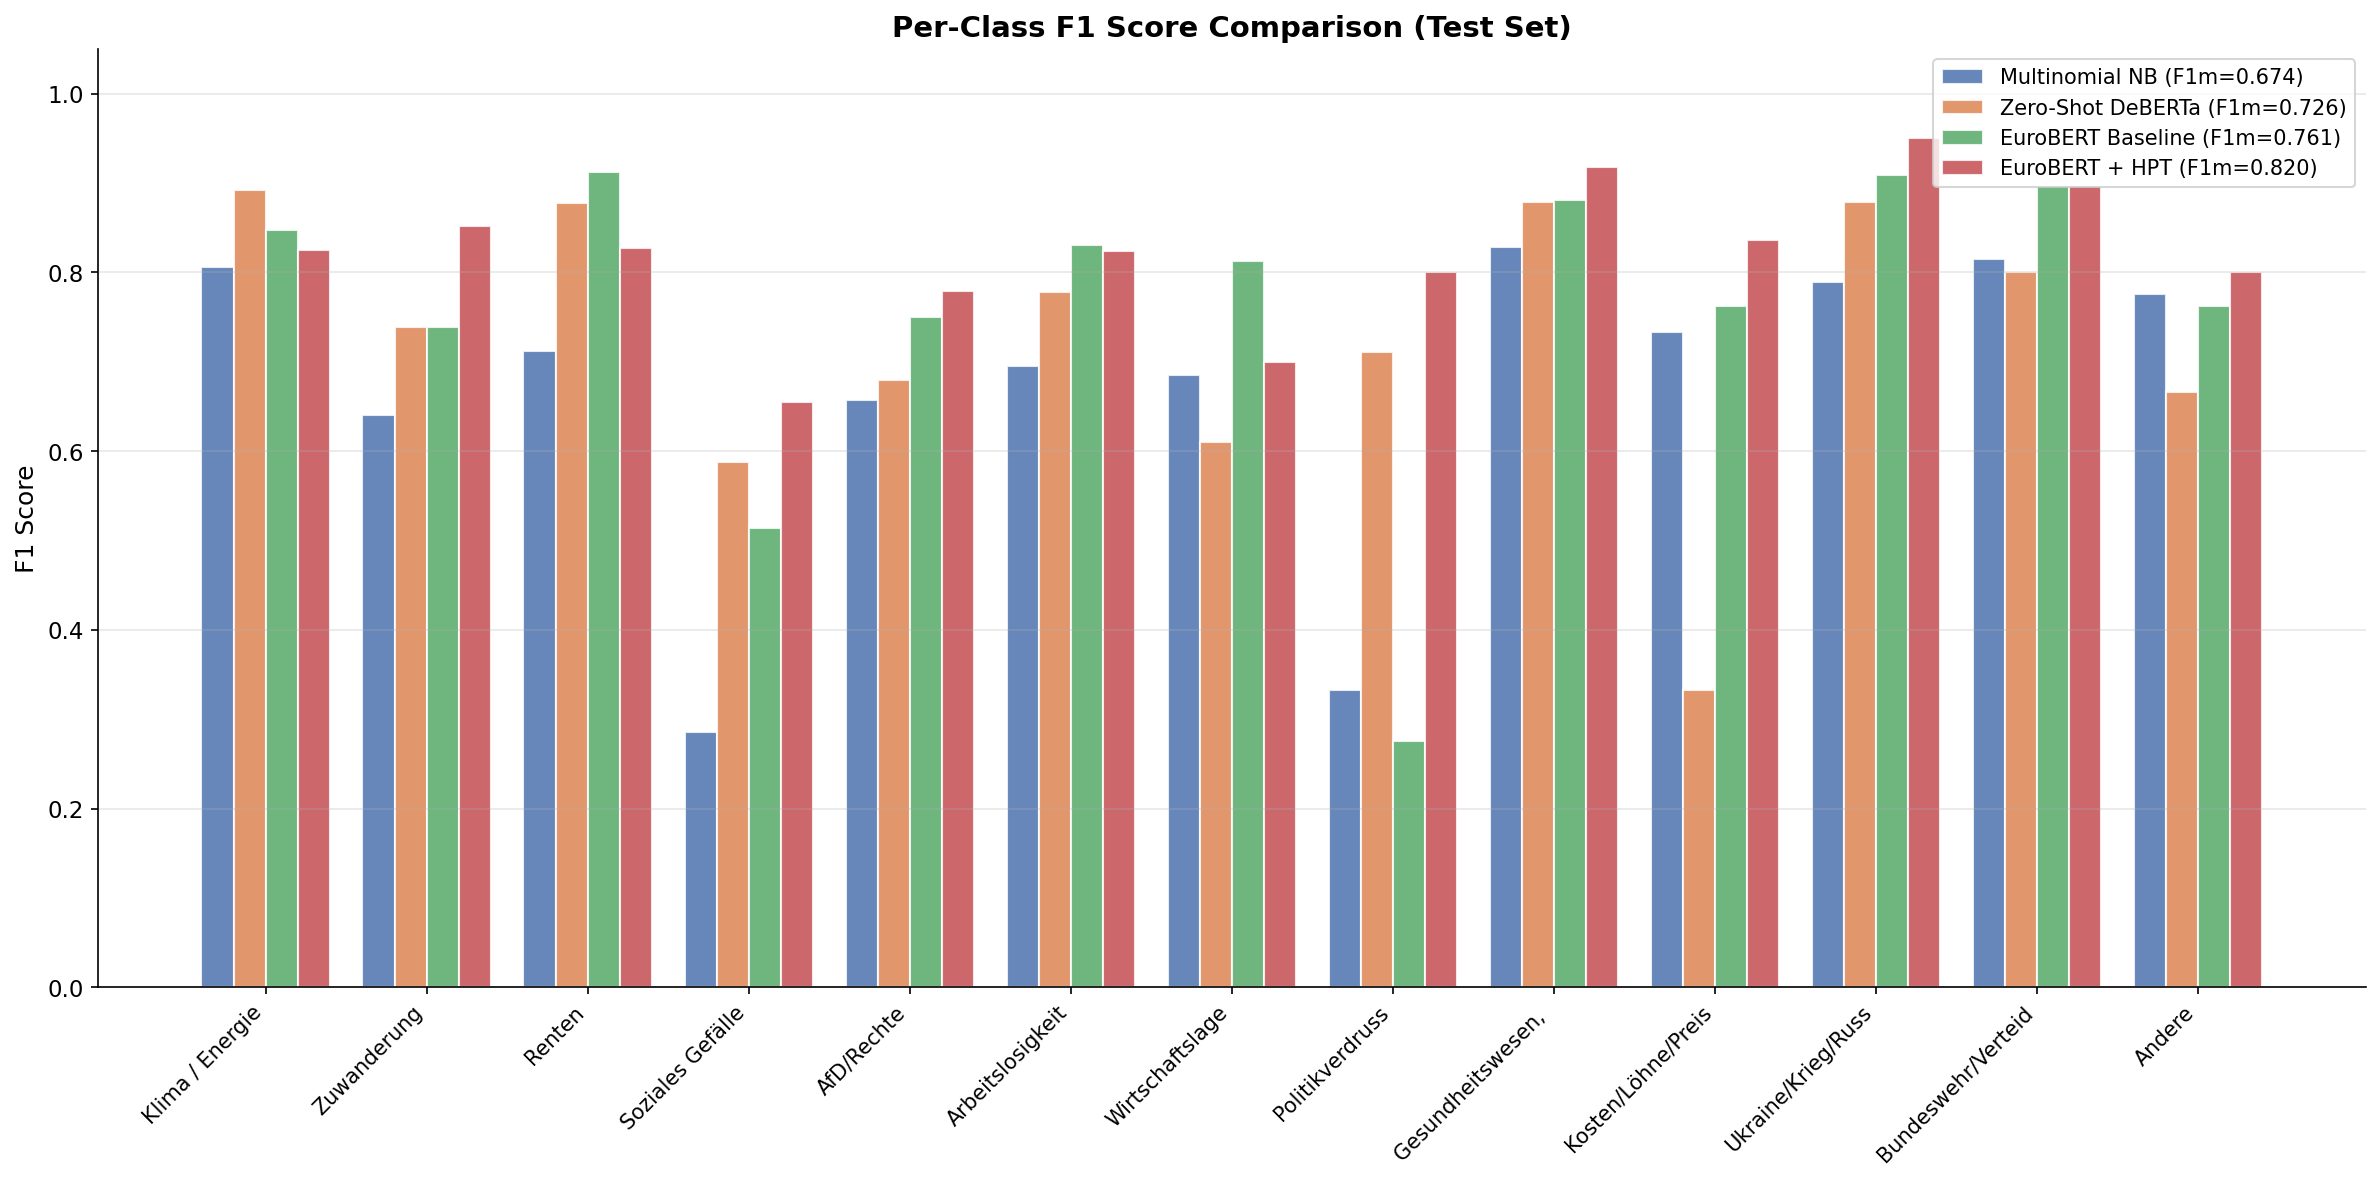

Saved: /Users/zorbeyozcan/news_articles_classification_thesis/Python/classification_pipeline/local_output/overview_report/04_per_class_f1_all_models.png


In [14]:
# === PLOT 4: PER-CLASS F1 (all 13 classes, all 4 models) ===
fig, ax = plt.subplots(figsize=(16, 8))

n_labels = len(ALL_LABELS)
n_models = len(MODEL_NAMES)
x = np.arange(n_labels)
width = 0.8 / n_models

for i, (name, m) in enumerate(zip(MODEL_NAMES, all_metrics)):
    f1_vals = m["per_class_df"]["F1"].values
    offset = (i - n_models / 2 + 0.5) * width
    bars = ax.bar(x + offset, f1_vals, width, label=f"{name} (F1m={m['f1_macro']:.3f})",
                  color=MODEL_COLORS[i], alpha=0.85, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels([l[:18] for l in ALL_LABELS], rotation=45, ha="right", fontsize=10)
ax.set_ylabel("F1 Score", fontsize=12)
ax.set_title("Per-Class F1 Score Comparison (Test Set)", fontsize=14, fontweight="bold")
ax.set_ylim(0, 1.05)
ax.legend(loc="upper right", fontsize=10)
ax.grid(axis="y", alpha=0.3)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
save_path = OUTPUT_DIR / "04_per_class_f1_all_models.png"
fig.savefig(save_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {save_path}")

---
## CSV Export: Full Metrics Table

In [15]:
# === CSV EXPORT ===

# --- Sheet 1: Aggregate metrics ---
csv_aggregate = OUTPUT_DIR / "metrics_aggregate.csv"
overview_df.to_csv(csv_aggregate, index=False)
print(f"Saved: {csv_aggregate}")

# --- Sheet 2: Per-class metrics (all models, all metrics) ---
csv_perclass = OUTPUT_DIR / "metrics_per_class.csv"
perclass_df.to_csv(csv_perclass, index=False)
print(f"Saved: {csv_perclass}")

# --- Sheet 3: Pairwise F1 for difficult pairs ---
csv_pairwise = OUTPUT_DIR / "metrics_pairwise_f1.csv"
pair_export = pair_df[["Pair", "Model", "F1 Macro (pair)"]].copy()
pair_export["Pair"] = pair_export["Pair"].str.replace("\n", " ")
pair_export.to_csv(csv_pairwise, index=False)
print(f"Saved: {csv_pairwise}")

# --- Sheet 4: Combined single CSV with everything ---
csv_combined = OUTPUT_DIR / "metrics_combined_all.csv"

combined_rows = []
for name, m in zip(MODEL_NAMES, all_metrics):
    pc = m["per_class_df"]
    for _, row in pc.iterrows():
        combined_rows.append({
            "Model": name,
            "Label": row["Label"],
            "Precision": round(row["Precision"], 4),
            "Recall": round(row["Recall"], 4),
            "F1": round(row["F1"], 4),
            "Support": int(row["Support"]),
            # Aggregate metrics repeated for easy filtering
            "F1_Macro": round(m["f1_macro"], 4),
            "F1_Weighted": round(m["f1_weighted"], 4),
            "Precision_Macro": round(m["precision_macro"], 4),
            "Recall_Macro": round(m["recall_macro"], 4),
            "Accuracy": round(m["accuracy"], 4),
        })

combined_df = pd.DataFrame(combined_rows)
combined_df.to_csv(csv_combined, index=False)
print(f"Saved: {csv_combined}")

print(f"\nAll CSV files saved to: {OUTPUT_DIR}")

Saved: /Users/zorbeyozcan/news_articles_classification_thesis/Python/classification_pipeline/local_output/overview_report/metrics_aggregate.csv
Saved: /Users/zorbeyozcan/news_articles_classification_thesis/Python/classification_pipeline/local_output/overview_report/metrics_per_class.csv
Saved: /Users/zorbeyozcan/news_articles_classification_thesis/Python/classification_pipeline/local_output/overview_report/metrics_pairwise_f1.csv
Saved: /Users/zorbeyozcan/news_articles_classification_thesis/Python/classification_pipeline/local_output/overview_report/metrics_combined_all.csv

All CSV files saved to: /Users/zorbeyozcan/news_articles_classification_thesis/Python/classification_pipeline/local_output/overview_report


---
## Summary

In [16]:
# === FINAL SUMMARY ===
print("=" * 70)
print("  MODEL COMPARISON OVERVIEW -- COMPLETE (Local)")
print("=" * 70)
print(f"  Test set: {len(test_df)} articles")
print(f"  Classes:  {len(ALL_LABELS)}")
print()
print(f"  {'Model':<25} {'F1 Macro':>10} {'Accuracy':>10} {'Prec Macro':>12} {'Rec Macro':>10}")
print(f"  {'-'*67}")
for name, m in zip(MODEL_NAMES, all_metrics):
    print(f"  {name:<25} {m['f1_macro']:>10.4f} {m['accuracy']:>10.4f} "
          f"{m['precision_macro']:>12.4f} {m['recall_macro']:>10.4f}")
print()
print(f"  Output directory: {OUTPUT_DIR}")
print(f"  Files:")
for f in sorted(OUTPUT_DIR.iterdir()):
    print(f"    - {f.name}")
print("=" * 70)
print("\nDone.")

  MODEL COMPARISON OVERVIEW -- COMPLETE (Local)
  Test set: 385 articles
  Classes:  13

  Model                       F1 Macro   Accuracy   Prec Macro  Rec Macro
  -------------------------------------------------------------------
  Multinomial NB                0.6737     0.7013       0.7791     0.6949
  Zero-Shot DeBERTa             0.7255     0.7351       0.7505     0.7338
  EuroBERT Baseline             0.7609     0.7766       0.8078     0.7687
  EuroBERT + HPT                0.8204     0.8182       0.8387     0.8169

  Output directory: /Users/zorbeyozcan/news_articles_classification_thesis/Python/classification_pipeline/local_output/overview_report
  Files:
    - 01_f1_macro_overview.png
    - 02_confusion_matrices.png
    - 03_pairwise_f1_difficult_pairs.png
    - 03b_f1_politikverdruss_soziales_gefaelle.png
    - 04_per_class_f1_all_models.png
    - metrics_aggregate.csv
    - metrics_combined_all.csv
    - metrics_pairwise_f1.csv
    - metrics_per_class.csv

Done.
